<a href="https://colab.research.google.com/github/jairbenavides0520-dotcom/Jair/blob/main/Actividades/Actividad%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

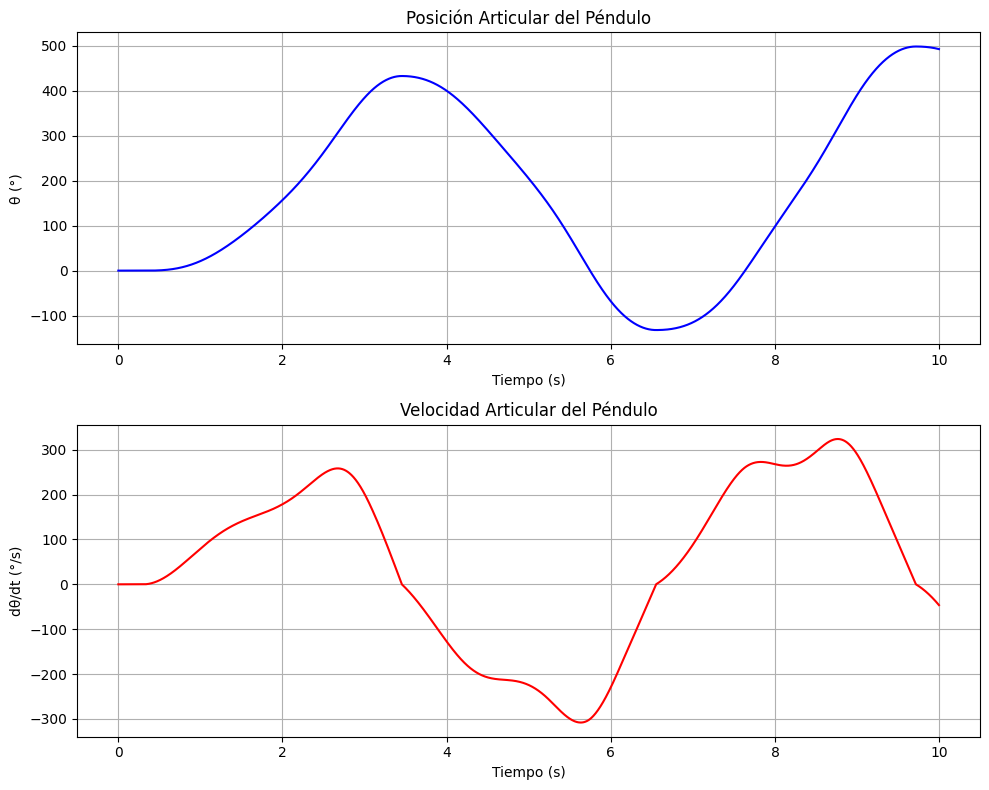

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def f(t, x):
    m = 5.0
    lc = 0.01
    g = 9.81
    b = 0.14
    fc = 0.45
    Ir = 0.16

    q = x[0]
    qp = x[1]

    tau_motor = tau(t)

    friccion_coulomb = fc * np.tanh(100000 * qp)

    qpp = (1/Ir) * (tau_motor - m*g*lc*np.sin(q) - b*qp - friccion_coulomb)

    dxdt = [qp, qpp]

    return dxdt

def tau(t):
    return 1.5 * np.sin(t)

ti = 0.0
tf = 10.0
h = 0.0025

ts = np.arange(ti, tf, h)

q0 = 0.0
qp0 = 0.0
x0 = [q0, qp0]

sol = solve_ivp(f, [ti, tf], x0, t_eval=ts)

t = sol.t

posicion = sol.y[0]
velocidad = sol.y[1]

posicion_grados = np.rad2deg(posicion)
velocidad_grados = np.rad2deg(velocidad)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t, posicion_grados, 'b-', label='Posición (q)')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Posición Articular del Péndulo')
ax1.grid(True)

ax2.plot(t, velocidad_grados, 'r-', label='Velocidad (qp)')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('dθ/dt (°/s)')
ax2.set_title('Velocidad Articular del Péndulo')
ax2.grid(True)

plt.tight_layout()
plt.show()